In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Load dataset
housing_data = fetch_california_housing()
housing_df = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)

# Add target column
housing_df['PRICE'] = housing_data.target

print("Shape:", housing_df.shape)
print("\nColumns:\n", housing_df.columns)
print("\nSummary:\n", housing_df.describe())

Shape: (20640, 9)

Columns:
 Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'PRICE'],
      dtype='str')

Summary:
              MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         PRICE  
count  20640.000000  20640.000000  20640.00

In [2]:
housing_df.loc[housing_df.sample(frac=0.05, random_state=42).index, 'MedInc'] = np.nan

print("\nMissing Values:\n", housing_df.isnull().sum())


Missing Values:
 MedInc        1032
HouseAge         0
AveRooms         0
AveBedrms        0
Population       0
AveOccup         0
Latitude         0
Longitude        0
PRICE            0
dtype: int64


In [3]:
housing_df.fillna(housing_df.mean(), inplace=True)

print("\nMissing Values After Handling:\n", housing_df.isnull().sum())


Missing Values After Handling:
 MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
PRICE         0
dtype: int64


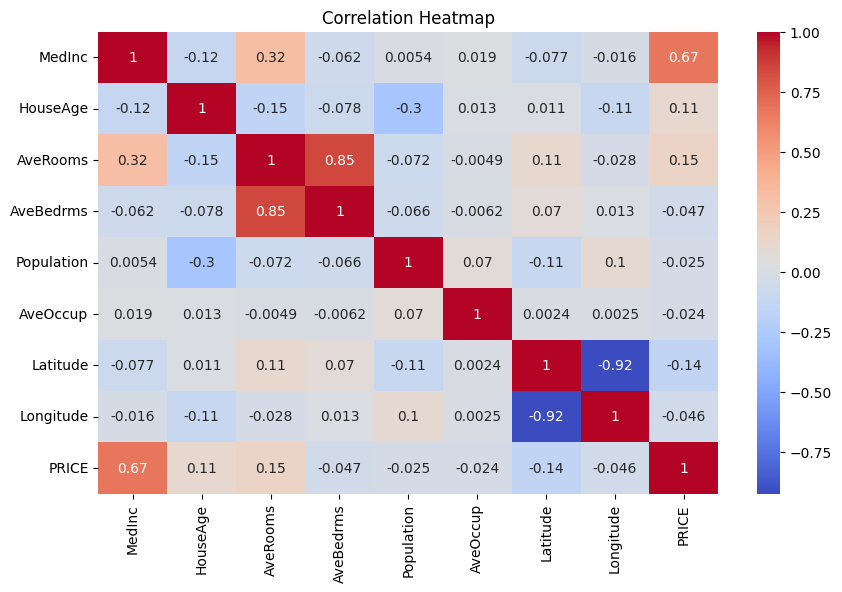

In [4]:
plt.figure(figsize=(10,6))
sns.heatmap(housing_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [5]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return outliers, lower_bound, upper_bound

outliers_price, lower_bound, upper_bound = detect_outliers_iqr(housing_df, 'PRICE')

print("Number of outliers in PRICE:", len(outliers_price))
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Number of outliers in PRICE: 1071
Lower bound: -0.9808749999999995
Upper bound: 4.824124999999999


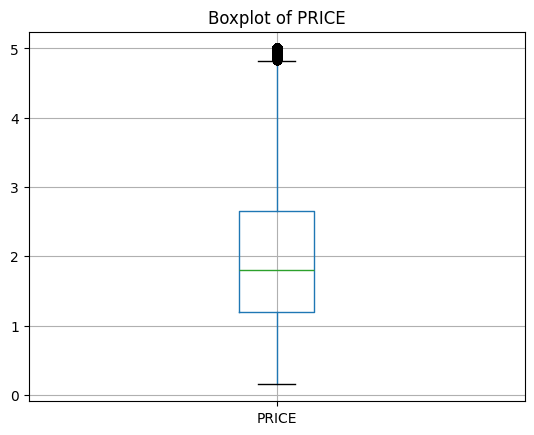

In [6]:
housing_df.boxplot(column='PRICE')
plt.title("Boxplot of PRICE")
plt.show()

In [7]:
housing_df_clean = housing_df[
    (housing_df['PRICE'] >= lower_bound) &
    (housing_df['PRICE'] <= upper_bound)
]

print("Original dataset shape:", housing_df.shape)
print("Cleaned dataset shape:", housing_df_clean.shape)
print("Removed", len(housing_df) - len(housing_df_clean), "outliers")

Original dataset shape: (20640, 9)
Cleaned dataset shape: (19569, 9)
Removed 1071 outliers


In [ ]:
X = housing_df.drop("PRICE", axis=1) #all coloumns except price
y = housing_df["PRICE"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10
)

In [ ]:
scaler = StandardScaler()
#we normalised the values here so that we can pass this data to ml models like linearRegression()
X_train_scaled = scaler.fit_transform(X_train) #fit finds means and std and transform normalises it
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) #lower rmse means better model
r2 = r2_score(y_test, y_pred) #Higher R² is better.

print("\nOriginal Model Performance")
print("RMSE:", rmse)
print("R2 Score:", r2)  #accuracy of the model


Original Model Performance
RMSE: 0.7630393710684302
R2 Score: 0.5733179825887755


In [11]:
X_clean = housing_df_clean.drop("PRICE", axis=1)
y_clean = housing_df_clean["PRICE"]

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=10
)

X_train_clean_scaled = scaler.fit_transform(X_train_clean)
X_test_clean_scaled = scaler.transform(X_test_clean)

model_clean = LinearRegression()
model_clean.fit(X_train_clean_scaled, y_train_clean)

y_pred_clean = model_clean.predict(X_test_clean_scaled)

In [12]:
rmse_clean = np.sqrt(mean_squared_error(y_test_clean, y_pred_clean))
r2_clean = r2_score(y_test_clean, y_pred_clean)

print("\nCleaned Model Performance")
print("RMSE:", rmse_clean)
print("R2 Score:", r2_clean)


Cleaned Model Performance
RMSE: 0.6360018167707526
R2 Score: 0.5482498878249924


In [13]:
print("\nComparison:")
print("Original RMSE:", rmse, "Cleaned RMSE:", rmse_clean)
print("Original R2:", r2, "Cleaned R2:", r2_clean)


Comparison:
Original RMSE: 0.7630393710684302 Cleaned RMSE: 0.6360018167707526
Original R2: 0.5733179825887755 Cleaned R2: 0.5482498878249924
